FIRST 5 ROWS
   Area  Bedrooms  Bathrooms  Floor  AgeOfProperty      Furnishing Parking  \
0  1811         1          2      5             10       Furnished     Yes   
1   434         2          1     10              1       Furnished     Yes   
2  2468         2          2      9             14       Furnished     Yes   
3  1989         4          2      3             15     Unfurnished      No   
4  1860         5          3      5              0  Semi-Furnished      No   

        City    Rent  
0      Delhi   78641  
1      Delhi   44906  
2      Delhi  107895  
3  Bangalore   90573  
4       Pune   91647  

Dataset Shape:
(1200, 9)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Area           1200 non-null   int64
 1   Bedrooms       1200 non-null   int64
 2   Bathrooms      1200 non-null   int64
 3   Floor          1200 no

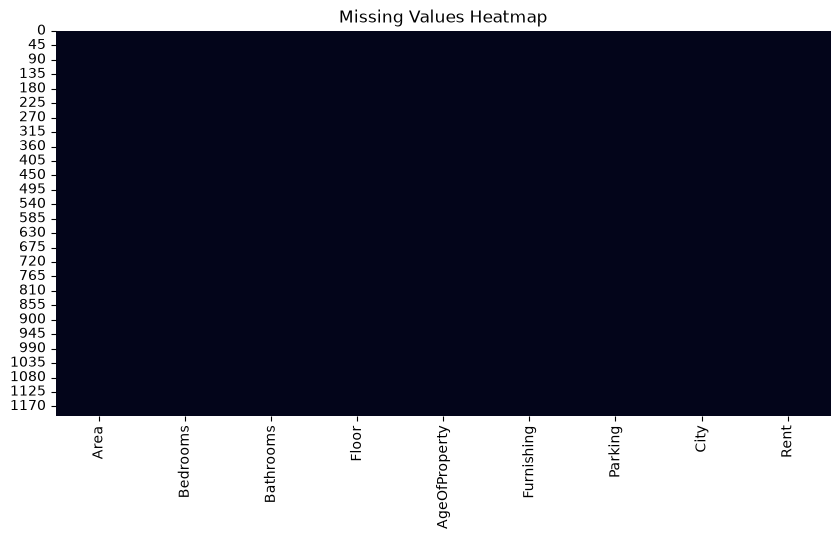

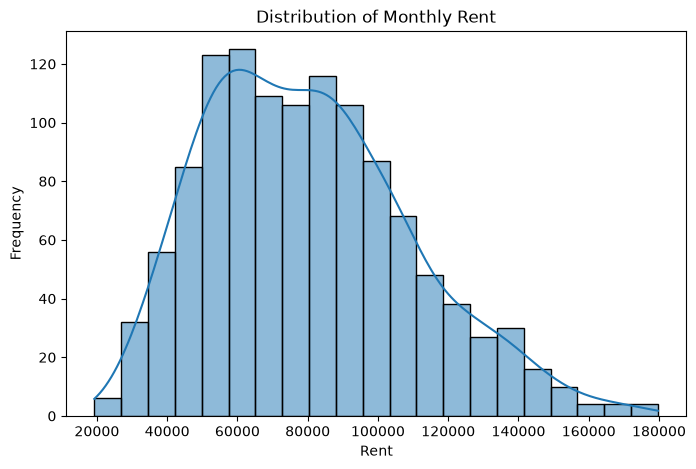

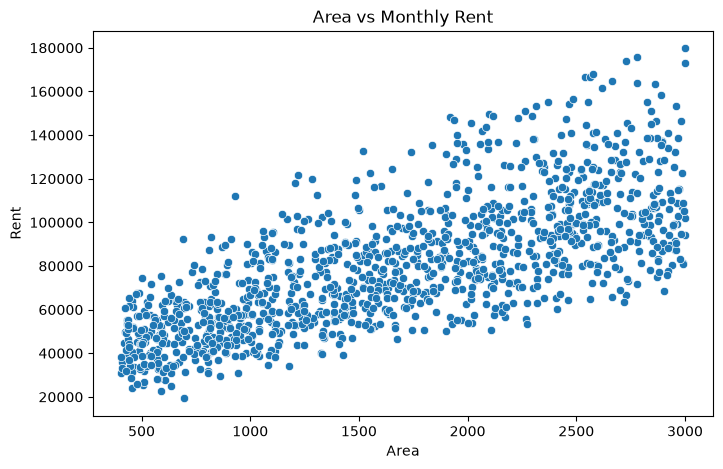

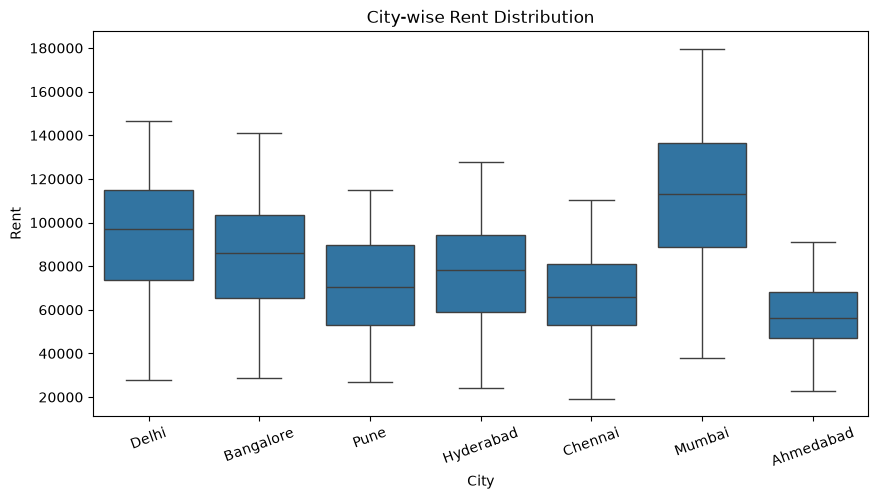

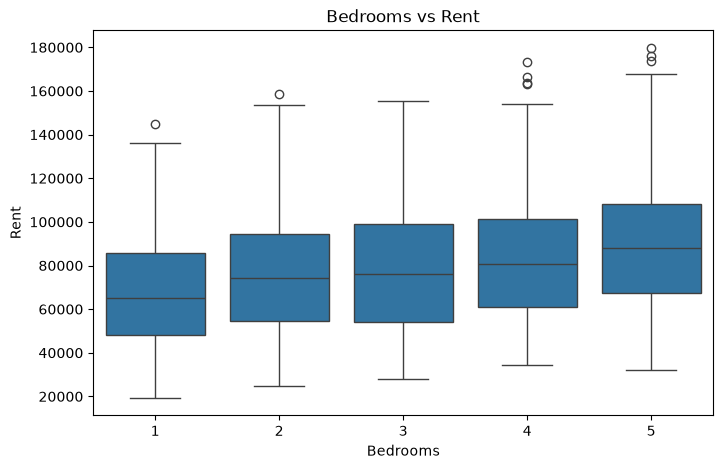

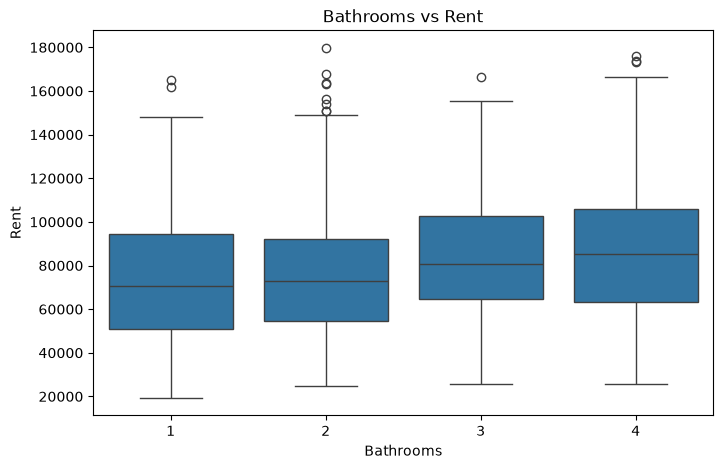

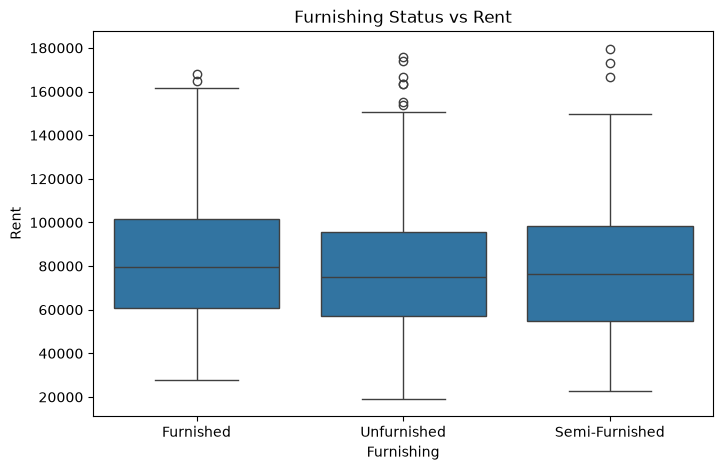

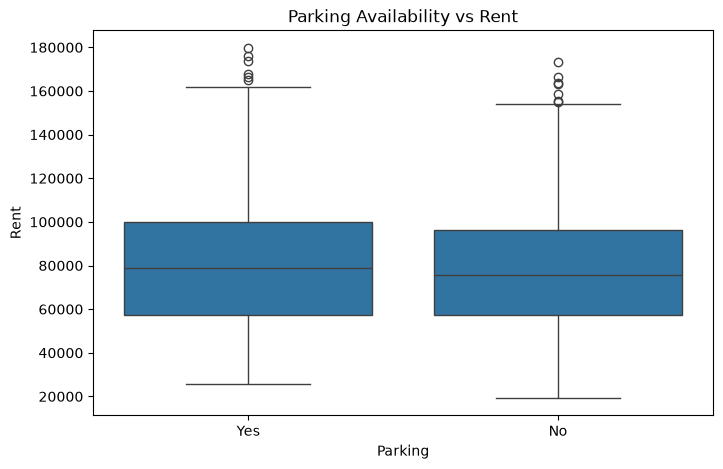

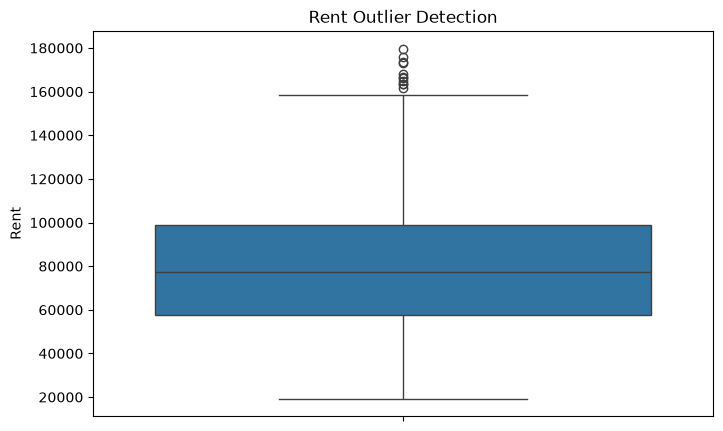

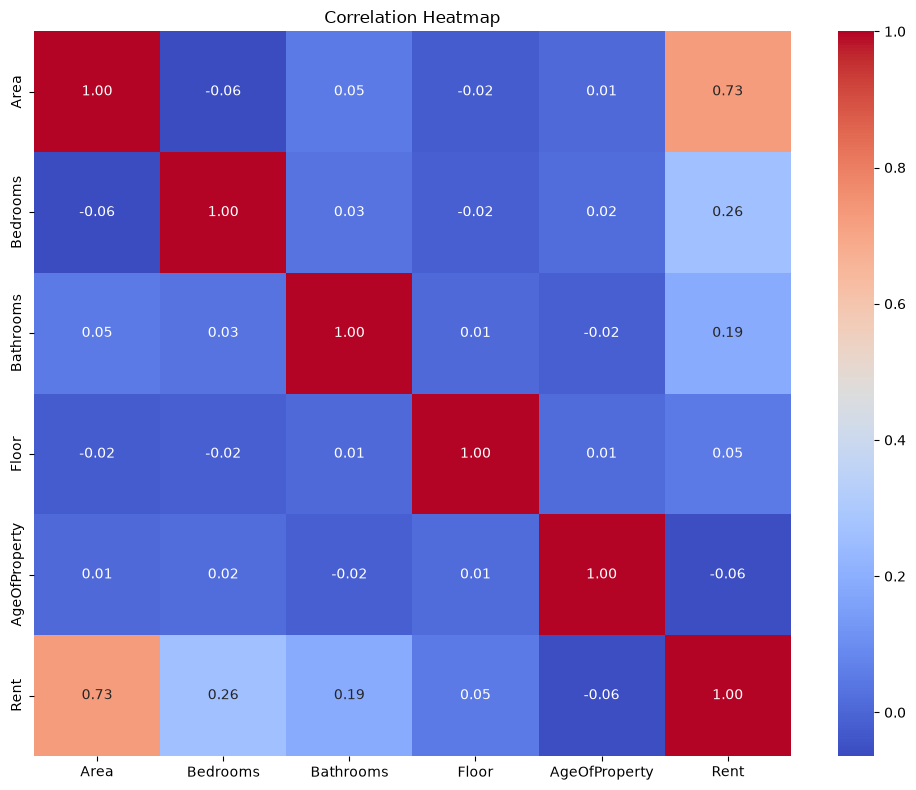


Model R² Score: 0.9803

KEY FINDINGS
- Area has a strong impact on rent.
- Furnished properties generally command higher rents.
- Parking availability increases rental value.
- Rent varies significantly across cities.
- Bedrooms and bathrooms contribute to rent prediction.


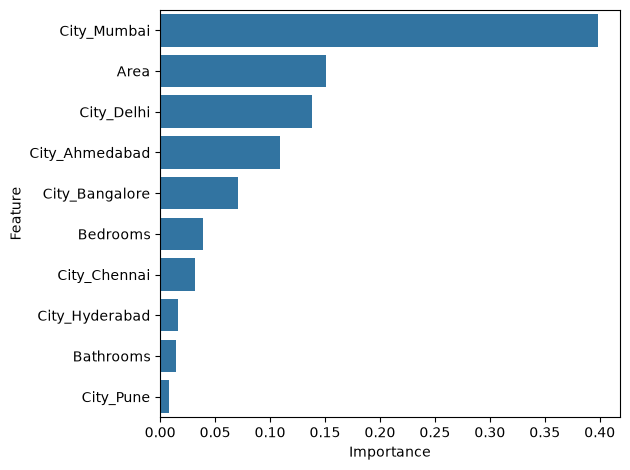

In [ ]:
# HOUSE RENT PREDICTION - ADVANCED EDA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

# 1. LOAD DATA
df = pd.read_csv("../data/house_rent_dataset.csv")

print("=" * 50)
print("FIRST 5 ROWS")
print("=" * 50)
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nSummary Statistics:")
print(df.describe(include='all'))

print("\nMissing Values:")
print(df.isnull().sum())

# 2. MISSING VALUE VISUALIZATION

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

# 3. TARGET VARIABLE ANALYSIS

plt.figure(figsize=(8, 5))
sns.histplot(df["Rent"], kde=True)
plt.title("Distribution of Monthly Rent")
plt.xlabel("Rent")
plt.ylabel("Frequency")
plt.show()

# 4. AREA VS RENT

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Area",
    y="Rent"
)
plt.title("Area vs Monthly Rent")
plt.show()

# 5. CITY VS RENT

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x="City",
    y="Rent"
)
plt.title("City-wise Rent Distribution")
plt.xticks(rotation=20)
plt.show()

# 6. BEDROOMS VS RENT

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Bedrooms",
    y="Rent"
)
plt.title("Bedrooms vs Rent")
plt.show()

# 7. BATHROOMS VS RENT


plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Bathrooms",
    y="Rent"
)
plt.title("Bathrooms vs Rent")
plt.show()

# 8. FURNISHING VS RENT


plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Furnishing",
    y="Rent"
)
plt.title("Furnishing Status vs Rent")
plt.show()

# 9. PARKING VS RENT

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Parking",
    y="Rent"
)
plt.title("Parking Availability vs Rent")
plt.show()


plt.figure(figsize=(8, 5))
sns.boxplot(
    y=df["Rent"]
)
plt.title("Rent Outlier Detection")
plt.show()


numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()
# 12. FEATURE IMPORTANCE USING XGBOOST

df_encoded = pd.get_dummies(
    df,
    columns=["Furnishing", "Parking", "City"],
    dtype=int
)

X = df_encoded.drop("Rent", axis=1)
y = df_encoded["Rent"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = XGBRegressor(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")
print(f"\nModel R² Score: {r2:.4f}")

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

top_features = importance.head(10)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.tight_layout()
# 13. BUSINESS INSIGHTS

print("\nKEY FINDINGS")
print("- Area has a strong impact on rent.")
print("- Furnished properties generally command higher rents.")
print("- Parking availability increases rental value.")
print("- Rent varies significantly across cities.")
print("- Bedrooms and bathrooms contribute to rent prediction.")

